# Desafío - Introducción al Machine Learning
## Daniel Rojas López

### 1. Leer el archivo Retail_Invoices.xlsx y realizar un análisis de calidad de datos, para definir la calidad de la data entregada considerando valores anómalos, valores faltantes, etc. Limpia lo que sea necesario y realiza un análisis exploratorio de los datos considerando gráficos de distribuciones y correlaciones entre estos.

=== INFORMACIÓN GENERAL DEL DATASET ===
Dimensiones: 22190 filas, 6 columnas

Primeras filas:
  InvoiceNo InvoiceDate  CustomerID  Quantity  price_total  StockCode
0    536365  2010-12-01       17850        40       139.12          7
1    536366  2010-12-01       17850        12        22.20          2
2    536367  2010-12-01       13047        83       278.73         12
3    536368  2010-12-01       13047        15        70.05          4
4    536369  2010-12-01       13047         3        17.85          1

Tipos de datos:
InvoiceNo              object
InvoiceDate    datetime64[us]
CustomerID              int64
Quantity                int64
price_total           float64
StockCode               int64
dtype: object

Estadísticas descriptivas:
                      InvoiceDate    CustomerID      Quantity    price_total  \
count                       22190  22190.000000  22190.000000   22190.000000   
mean   2011-06-29 05:59:15.223073  15238.498738    221.130599     374.045327   
min    

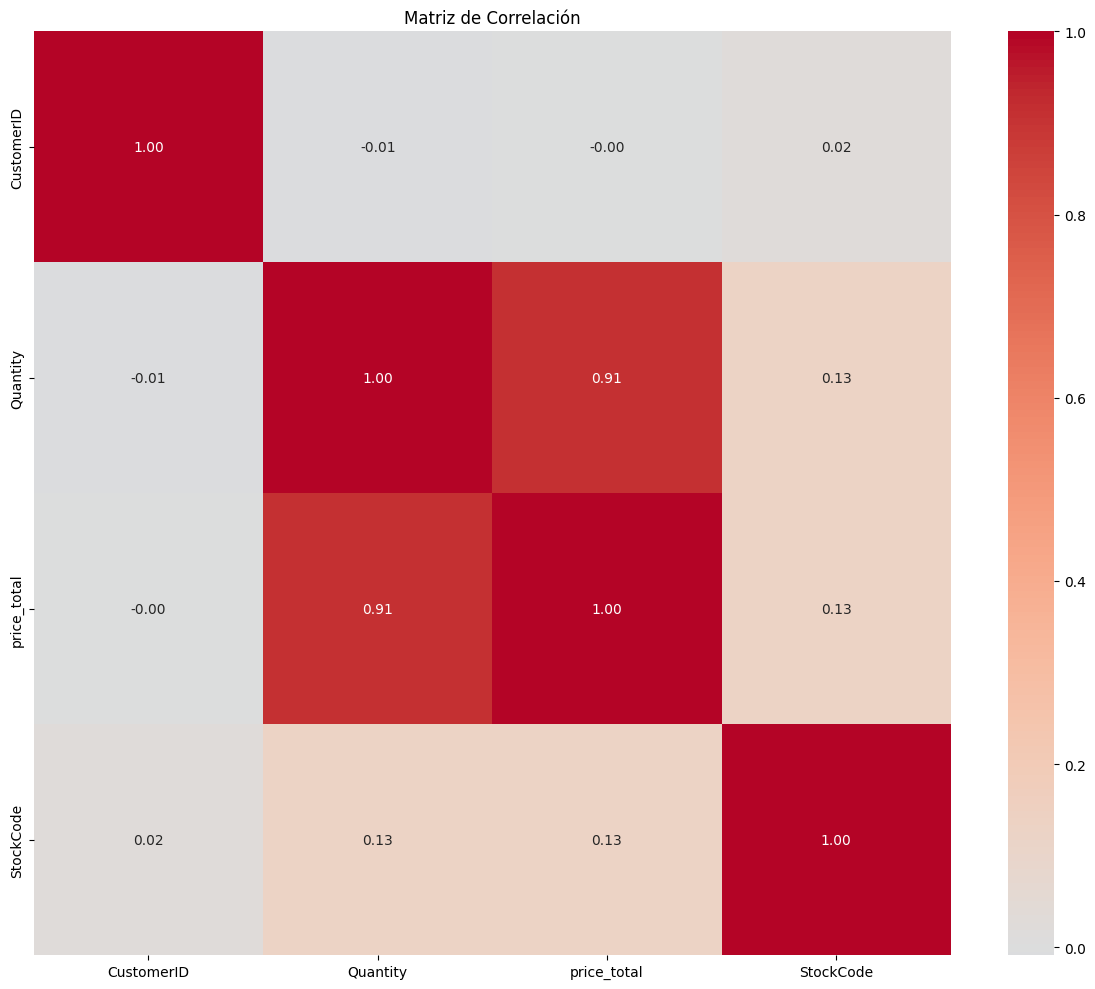

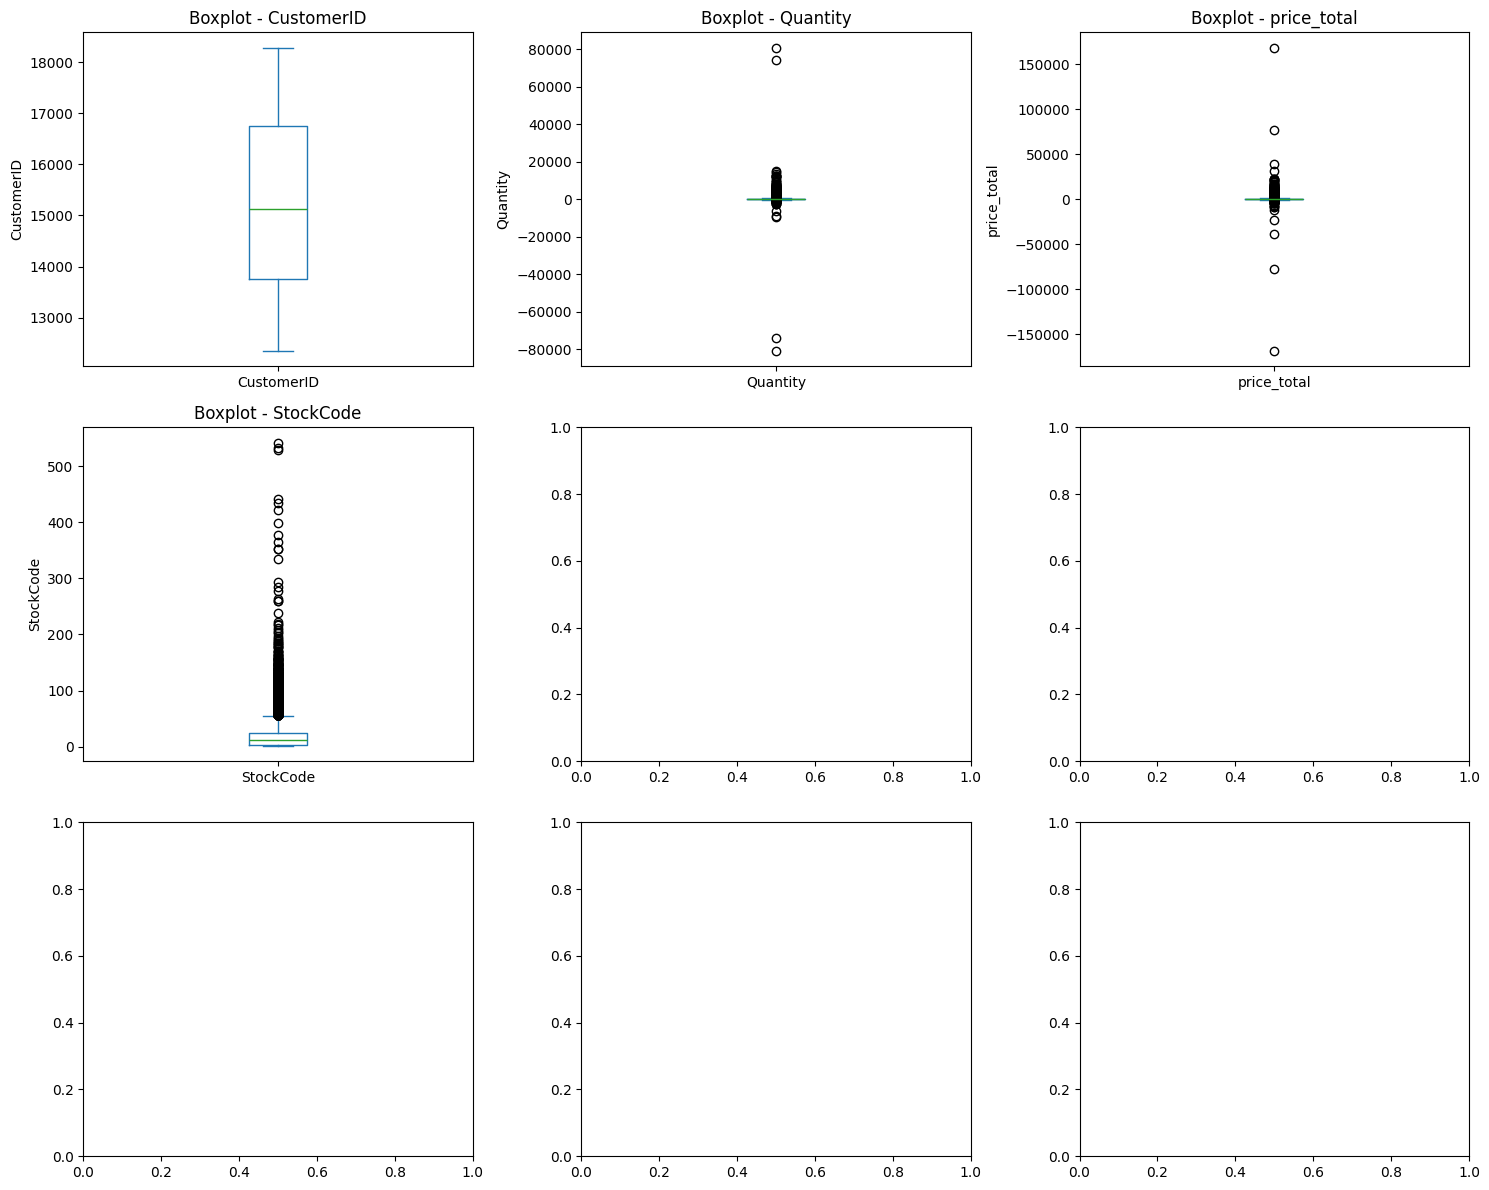

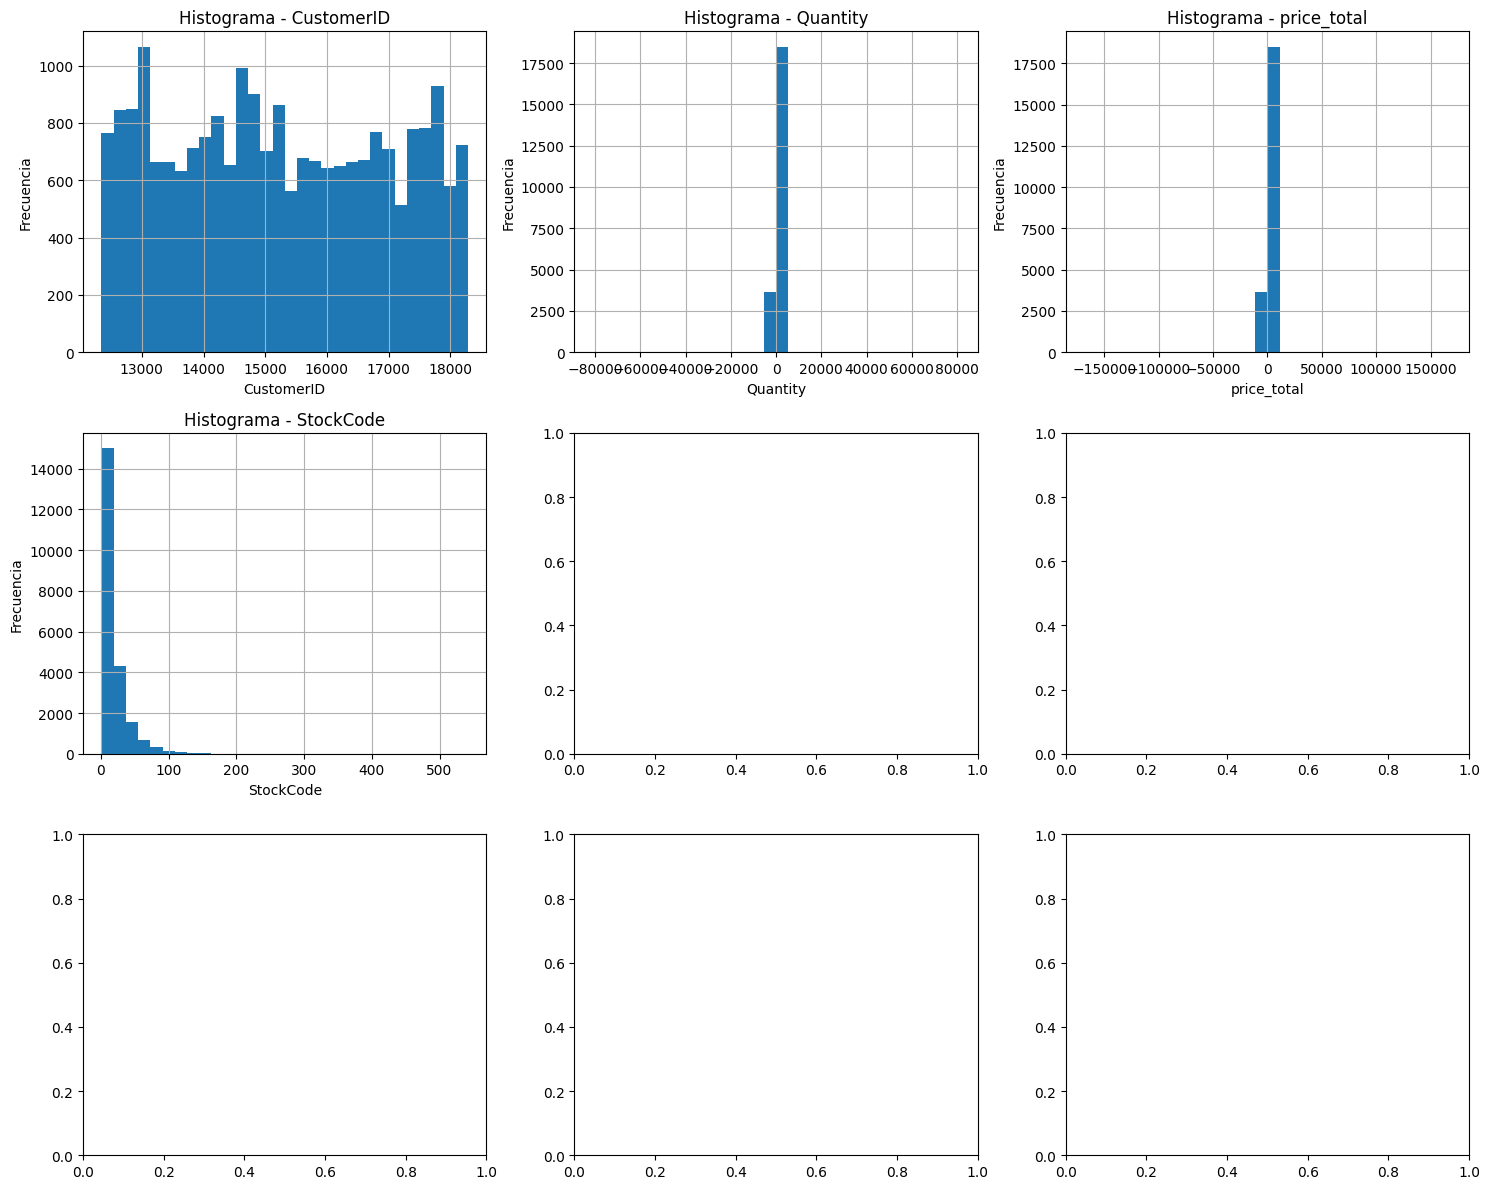


=== RESUMEN ===
El análisis de calidad de datos ha sido completado.
Se han identificado valores nulos, outliers y correlaciones entre variables.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar el archivo Retail_Invoices.xlsx
df = pd.read_excel('Retail_Invoices.xlsx')

# Mostrar las primeras filas y dimensiones
print("=== INFORMACIÓN GENERAL DEL DATASET ===")
print(f"Dimensiones: {df.shape[0]} filas, {df.shape[1]} columnas")
print("\nPrimeras filas:")
print(df.head())
print(f"\nTipos de datos:")
print(df.dtypes)
print(f"\nEstadísticas descriptivas:")
print(df.describe())

# Análisis de valores nulos
print("\n=== ANÁLISIS DE VALORES NULOS ===")
valores_nulos = df.isnull().sum()
print("Valores nulos por columna:")
print(valores_nulos)
print(f"\nPorcentaje de valores nulos:")
print((valores_nulos / len(df) * 100).round(2))

# Análisis de datos atípicos (outliers) usando el método IQR
print("\n=== ANÁLISIS DE DATOS ATÍPICOS (OUTLIERS) ===")
columnas_numericas = df.select_dtypes(include=[np.number]).columns

for col in columnas_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    outliers = df[(df[col] < limite_inferior) | (df[col] > limite_superior)]
    print(f"\n{col}:")
    print(f"  - Límite inferior: {limite_inferior:.2f}")
    print(f"  - Límite superior: {limite_superior:.2f}")
    print(f"  - Outliers detectados: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

# Análisis de datos extraños (valores fuera de rangos lógicos)
print("\n=== ANÁLISIS DE DATOS EXTRAÑOS ===")
print("Verificación de rangos lógicos:")
for col in columnas_numericas:
    negativos = (df[col] < 0).sum()
    if negativos > 0:
        print(f"  - {col} negativos: {negativos}")

# Análisis de correlaciones
print("\n=== ANÁLISIS DE CORRELACIONES ===")
matriz_correlacion = df.select_dtypes(include=[np.number]).corr()
print("Matriz de correlación:")
print(matriz_correlacion)

# Visualización de correlaciones
plt.figure(figsize=(12, 10))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

# Visualización de distribuciones y outliers
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(columnas_numericas):
    if i < 9:
        df[col].plot(kind='box', ax=axes[i])
        axes[i].set_title(f'Boxplot - {col}')
        axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# Visualización de distribuciones (histogramas)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(columnas_numericas):
    if i < 9:
        df[col].hist(ax=axes[i], bins=30)
        axes[i].set_title(f'Histograma - {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

print("\n=== RESUMEN ===")
print("El análisis de calidad de datos ha sido completado.")
print("Se han identificado valores nulos, outliers y correlaciones entre variables.")

### 2. Generar variables para la segmentación. Notar que la granularidad de la data es por boleta y se necesita segmentar clientes, por lo que es necesario generar variables a nivel de clientes. Se propone generar al menos RFM (Recencia, frecuencia y monto).

In [3]:
# Generar variables RFM (Recency, Frequency, Monetary) a nivel de cliente

# Primero, ver las columnas disponibles para identificar las necesarias
print("Columnas disponibles:")
print(df.columns.tolist())

# Identificar columnas clave basadas en nombres comunes
customer_col = None
date_col = None
amount_col = None

for col in df.columns:
    col_lower = col.lower()
    if 'customer' in col_lower or 'client' in col_lower or 'id' in col_lower:
        customer_col = col
    if 'date' in col_lower or 'time' in col_lower:
        date_col = col
    if 'amount' in col_lower or 'price' in col_lower or 'total' in col_lower or 'quantity' in col_lower:
        amount_col = col

print(f"\nColumnas identificadas automáticamente:")
print(f"Cliente: {customer_col}")
print(f"Fecha: {date_col}")
print(f"Monto: {amount_col}")

# Convertir fecha a datetime si es necesario
if date_col and df[date_col].dtype != 'datetime64[ns]':
    df[date_col] = pd.to_datetime(df[date_col])

# Calcular fecha de referencia (fecha más reciente en los datos + 1 día)
fecha_referencia = df[date_col].max() + pd.Timedelta(days=1)
print(f"\nFecha de referencia: {fecha_referencia}")

# Generar variables RFM
if customer_col and date_col and amount_col:
    # Recency: días desde la última compra del cliente
    recency = df.groupby(customer_col)[date_col].max().reset_index()
    recency.columns = [customer_col, 'UltimaCompra']
    recency['Recency'] = (fecha_referencia - recency['UltimaCompra']).dt.days
    
    # Frequency: número de compras del cliente
    frequency = df.groupby(customer_col).size().reset_index()
    frequency.columns = [customer_col, 'Frequency']
    
    # Monetary: monto total gastado por el cliente
    monetary = df.groupby(customer_col)[amount_col].sum().reset_index()
    monetary.columns = [customer_col, 'Monetary']
    
    # Combinar las tres métricas
    rfm = recency[[customer_col, 'Recency']].merge(frequency, on=customer_col)
    rfm = rfm.merge(monetary, on=customer_col)
    
    print(f"\n=== VARIABLES RFM GENERADAS ===")
    print(f"Número de clientes únicos: {len(rfm)}")
    print(f"\nPrimeras filas del dataset RFM:")
    print(rfm.head(10))
    
    print(f"\nEstadísticas descriptivas de RFM:")
    print(rfm.describe())
    
    # Guardar el dataframe RFM
    df_rfm = rfm
    print("\nDataset RFM guardado en variable 'df_rfm'")
    
else:
    print("\nNo se pudieron identificar todas las columnas necesarias.")
    print("Por favor, especifique manualmente las columnas para:")
    print("- ID de cliente")
    print("- Fecha de compra")
    print("- Monto de la compra")

Columnas disponibles:
['InvoiceNo', 'InvoiceDate', 'CustomerID', 'Quantity', 'price_total', 'StockCode']

Columnas identificadas automáticamente:
Cliente: CustomerID
Fecha: InvoiceDate
Monto: price_total

Fecha de referencia: 2011-12-10 00:00:00

=== VARIABLES RFM GENERADAS ===
Número de clientes únicos: 4372

Primeras filas del dataset RFM:
   CustomerID  Recency  Frequency  Monetary
0       12346      326          2      0.00
1       12347        3          7   4310.00
2       12348       76          4   1797.24
3       12349       19          1   1757.55
4       12350      311          1    334.40
5       12352       37         11   1545.41
6       12353      205          1     89.00
7       12354      233          1   1079.40
8       12355      215          1    459.40
9       12356       23          3   2811.43

Estadísticas descriptivas de RFM:
         CustomerID      Recency    Frequency       Monetary
count   4372.000000  4372.000000  4372.000000    4372.000000
mean   15299.67

### 3. Realizar un análisis exploratorio y las transformaciones necesarias las nuevas variables.

### 4.Aplicar al menos 2 algoritmos de clustering. Buscar el número indicado de clusters que puedan tener y visualizar los cluster resultantes de los algoritmos.

### 5.Evaluar la calidad de los clustering de forma numérica y realizar una explicación de cada segmento asignándoles un nombre descriptivo